In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [ ]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

In [ ]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:04:46  2024      1    1     0       4      46
1 2024-01-01 00:10:25  2024      1    1     0      10      25
2 2024-01-01 00:15:06  2024      1    1     0      15       6
3 2024-01-01 00:20:12  2024      1    1     0      20      12
4 2024-01-01 00:25:14  2024      1    1     0      25      14
5 2024-01-01 00:30:16  2024      1    1     0      30      16
6 2024-01-01 00:35:13  2024      1    1     0      35      13
7 2024-01-01 00:40:22  2024      1    1     0      40      22
8 2024-01-01 00:44:33  2024      1    1     0      44      33
9 2024-01-01 00:50:02  2024      1    1     0      50       2


In [ ]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 50,000 rows x 26 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [18]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0    15091
1    24941
2     9968
Name: count, dtype: int64


In [19]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 50,000 rows x 26 columns

Column types:
timestamp                           datetime64[ns]
slice_type                                   int64
latitude                                   float64
longitude                                  float64
one_way_latency_ms                         float64
jitter_ms                                  float64
rtt_ms                                     float64
packet_delay_budget_ms                     float64
handover_interruption_time_ms              float64
reliability_percent                        float64
packet_loss_percent                        float64
packet_loss_rate_percent                   float64
bler_percent                               float64
throughput_dl_mbps                         float64
throughput_ul_mbps                         float64
spectral_efficiency_bps_hz                 float64
handover_success_rate_percent              float64
energy_efficiency_bits_per_joule    

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:04:46,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024,1,1,0,4,46
1,2024-01-01 00:10:25,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024,1,1,0,10,25
2,2024-01-01 00:15:06,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal,2024,1,1,0,15,6
3,2024-01-01 00:20:12,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal,2024,1,1,0,20,12
4,2024-01-01 00:25:14,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024,1,1,0,25,14


In [20]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 50,000 rows x 26 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [21]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 23 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(47524), 1: np.int64(2476)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(319), 1: np.int64(280), 2: np.int64(316), 3: np.int

In [22]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (50000, 23)  (23 features)
  y1 shape: (50000,)  (binary)
  y2 shape: (50000,)  (multi-class, 9 classes)

  X dtypes:
slice_type                            int64
latitude                            float64
longitude                           float64
one_way_latency_ms                  float64
jitter_ms                           float64
rtt_ms                              float64
packet_delay_budget_ms              float64
handover_interruption_time_ms       float64
reliability_percent                 float64
packet_loss_percent                 float64
packet_loss_rate_percent            float64
bler_percent                        float64
throughput_dl_mbps                  float64
throughput_ul_mbps                  float64
spectral_efficiency_bps_hz          float64
handover_success_rate_percent       float64
energy_efficiency_bits_per_joule    float64
year                                  int32
month                                 int32
day        

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
0,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,2024,1,1,0,4,46
1,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,2024,1,1,0,10,25
2,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,2024,1,1,0,15,6
3,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,2024,1,1,0,20,12
4,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,2024,1,1,0,25,14


In [23]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y1_train distribution:
    Normal (0):  38,019 (95.05%)
    Anomaly (1): 1,981 (4.95%)

  y1_test distribution:
    Normal (0):  9,505 (95.05%)
    Anomaly (1): 495 (4.95%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y2_train distribution:
    backhaul_issue (0): 255 (0.64%)
    handover_failure (1): 224 (0.56%)
    hardware_failure (2): 253 (0.63%)
    interference (3): 247 (0.62%)
    network_congestion (4): 249 (0.62%)
    normal (5): 38,019 (95.05%)
    overload (6): 249 (0.62%)
    security_attack (7): 249 (0.62%)
    signal_degradation (8): 255 (0.64%)

  y2_test distribution:
    backhaul_issue (0): 64 (0.64%)
    handover_failure (1): 56 (0.56%)
    hardware_failure (2): 63 (0.63%)
    interference (3): 62 (0.62%)
    network_congestion (4): 62 (0.62%)
    normal (5): 9,505 (95.05%)
    overload (6): 62 (0.62%)
    security_at

## 4. Standardization (StandardScaler)

In [24]:
# =====================================================================
# 4.1 Apply StandardScaler
# =====================================================================
# Fit on training data ONLY, then transform both train and test sets
# This prevents data leakage from test set into training

scaler = StandardScaler()

# --- Binary classification sets ---
X_train_b_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_scaled = pd.DataFrame(
    scaler.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# --- Multi-class classification sets ---
scaler_m = StandardScaler()

X_train_m_scaled = pd.DataFrame(
    scaler_m.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_scaled = pd.DataFrame(
    scaler_m.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 4.2 Verification
# =====================================================================
print("="*70)
print("STANDARDIZATION - StandardScaler")
print("="*70)

print("--- Binary classification sets ---")
print(f"  X_train_b_scaled: {X_train_b_scaled.shape}")
print(f"  X_test_b_scaled:  {X_test_b_scaled.shape}")

print(" Train set statistics (mean ~ 0, std ~ 1):")
train_stats = pd.DataFrame({
    "Mean": X_train_b_scaled.mean().round(6),
    "Std": X_train_b_scaled.std().round(6)
})
print(train_stats)

print("Test set statistics:")
test_stats = pd.DataFrame({
    "Mean": X_test_b_scaled.mean().round(6),
    "Std": X_test_b_scaled.std().round(6)
})
print(test_stats)

print("--- Multi-class classification sets ---")
print(f"  X_train_m_scaled: {X_train_m_scaled.shape}")
print(f"  X_test_m_scaled:  {X_test_m_scaled.shape}")

print("Preview (X_train_b_scaled):")
X_train_b_scaled.head()

STANDARDIZATION - StandardScaler
--- Binary classification sets ---
  X_train_b_scaled: (40000, 23)
  X_test_b_scaled:  (10000, 23)
 Train set statistics (mean ~ 0, std ~ 1):
                                  Mean       Std
slice_type                        -0.0  1.000013
latitude                          -0.0  1.000013
longitude                         -0.0  1.000013
one_way_latency_ms                -0.0  1.000013
jitter_ms                         -0.0  1.000013
rtt_ms                            -0.0  1.000013
packet_delay_budget_ms             0.0  1.000013
handover_interruption_time_ms     -0.0  1.000013
reliability_percent               -0.0  1.000013
packet_loss_percent               -0.0  1.000013
packet_loss_rate_percent           0.0  1.000013
bler_percent                       0.0  1.000013
throughput_dl_mbps                -0.0  1.000013
throughput_ul_mbps                 0.0  1.000013
spectral_efficiency_bps_hz        -0.0  1.000013
handover_success_rate_percent      0.0  1

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
4210,0.148606,0.393241,-0.156627,-0.122978,-0.421797,-0.195227,0.226206,0.214459,0.199133,-0.141457,-0.241672,-0.270992,1.240259,1.569072,0.092905,0.092991,-0.540093,0.0,-1.436921,-0.021903,0.361913,1.412759,0.319115
16490,0.148606,1.078479,0.504794,-0.189540,-0.362939,-0.174399,0.893923,0.695093,0.225371,-0.166524,-0.245761,0.113520,-0.369201,0.907413,0.504506,-0.031747,-0.456819,0.0,-0.833572,1.365270,-0.793609,-0.890754,0.319115
48168,0.148606,-1.157168,0.986975,-0.119315,-0.003604,-0.126351,0.934000,0.190384,0.282801,-0.149786,-0.217704,-0.008151,0.557764,0.801354,0.366097,0.083448,-0.561125,0.0,1.579824,0.093695,-0.793609,-1.409044,-0.611877
9745,-1.278927,0.608440,-1.445086,-0.241066,-0.616916,-0.302687,-1.356240,-0.682123,0.453759,-0.338310,-0.334421,-0.772825,-0.833825,-0.834950,-0.314870,-0.016141,0.819934,0.0,-0.833572,-1.409076,1.228555,-1.121105,-1.484682
32778,0.148606,1.209304,-1.327061,-0.191107,-0.174753,-0.165265,0.494451,0.099591,0.194546,-0.229155,-0.238315,0.533141,1.099516,0.501243,0.527914,-0.052044,-0.424517,0.0,0.373126,0.902879,1.084115,0.318590,-1.659243


## 5. Distribution des Features apres Standardisation

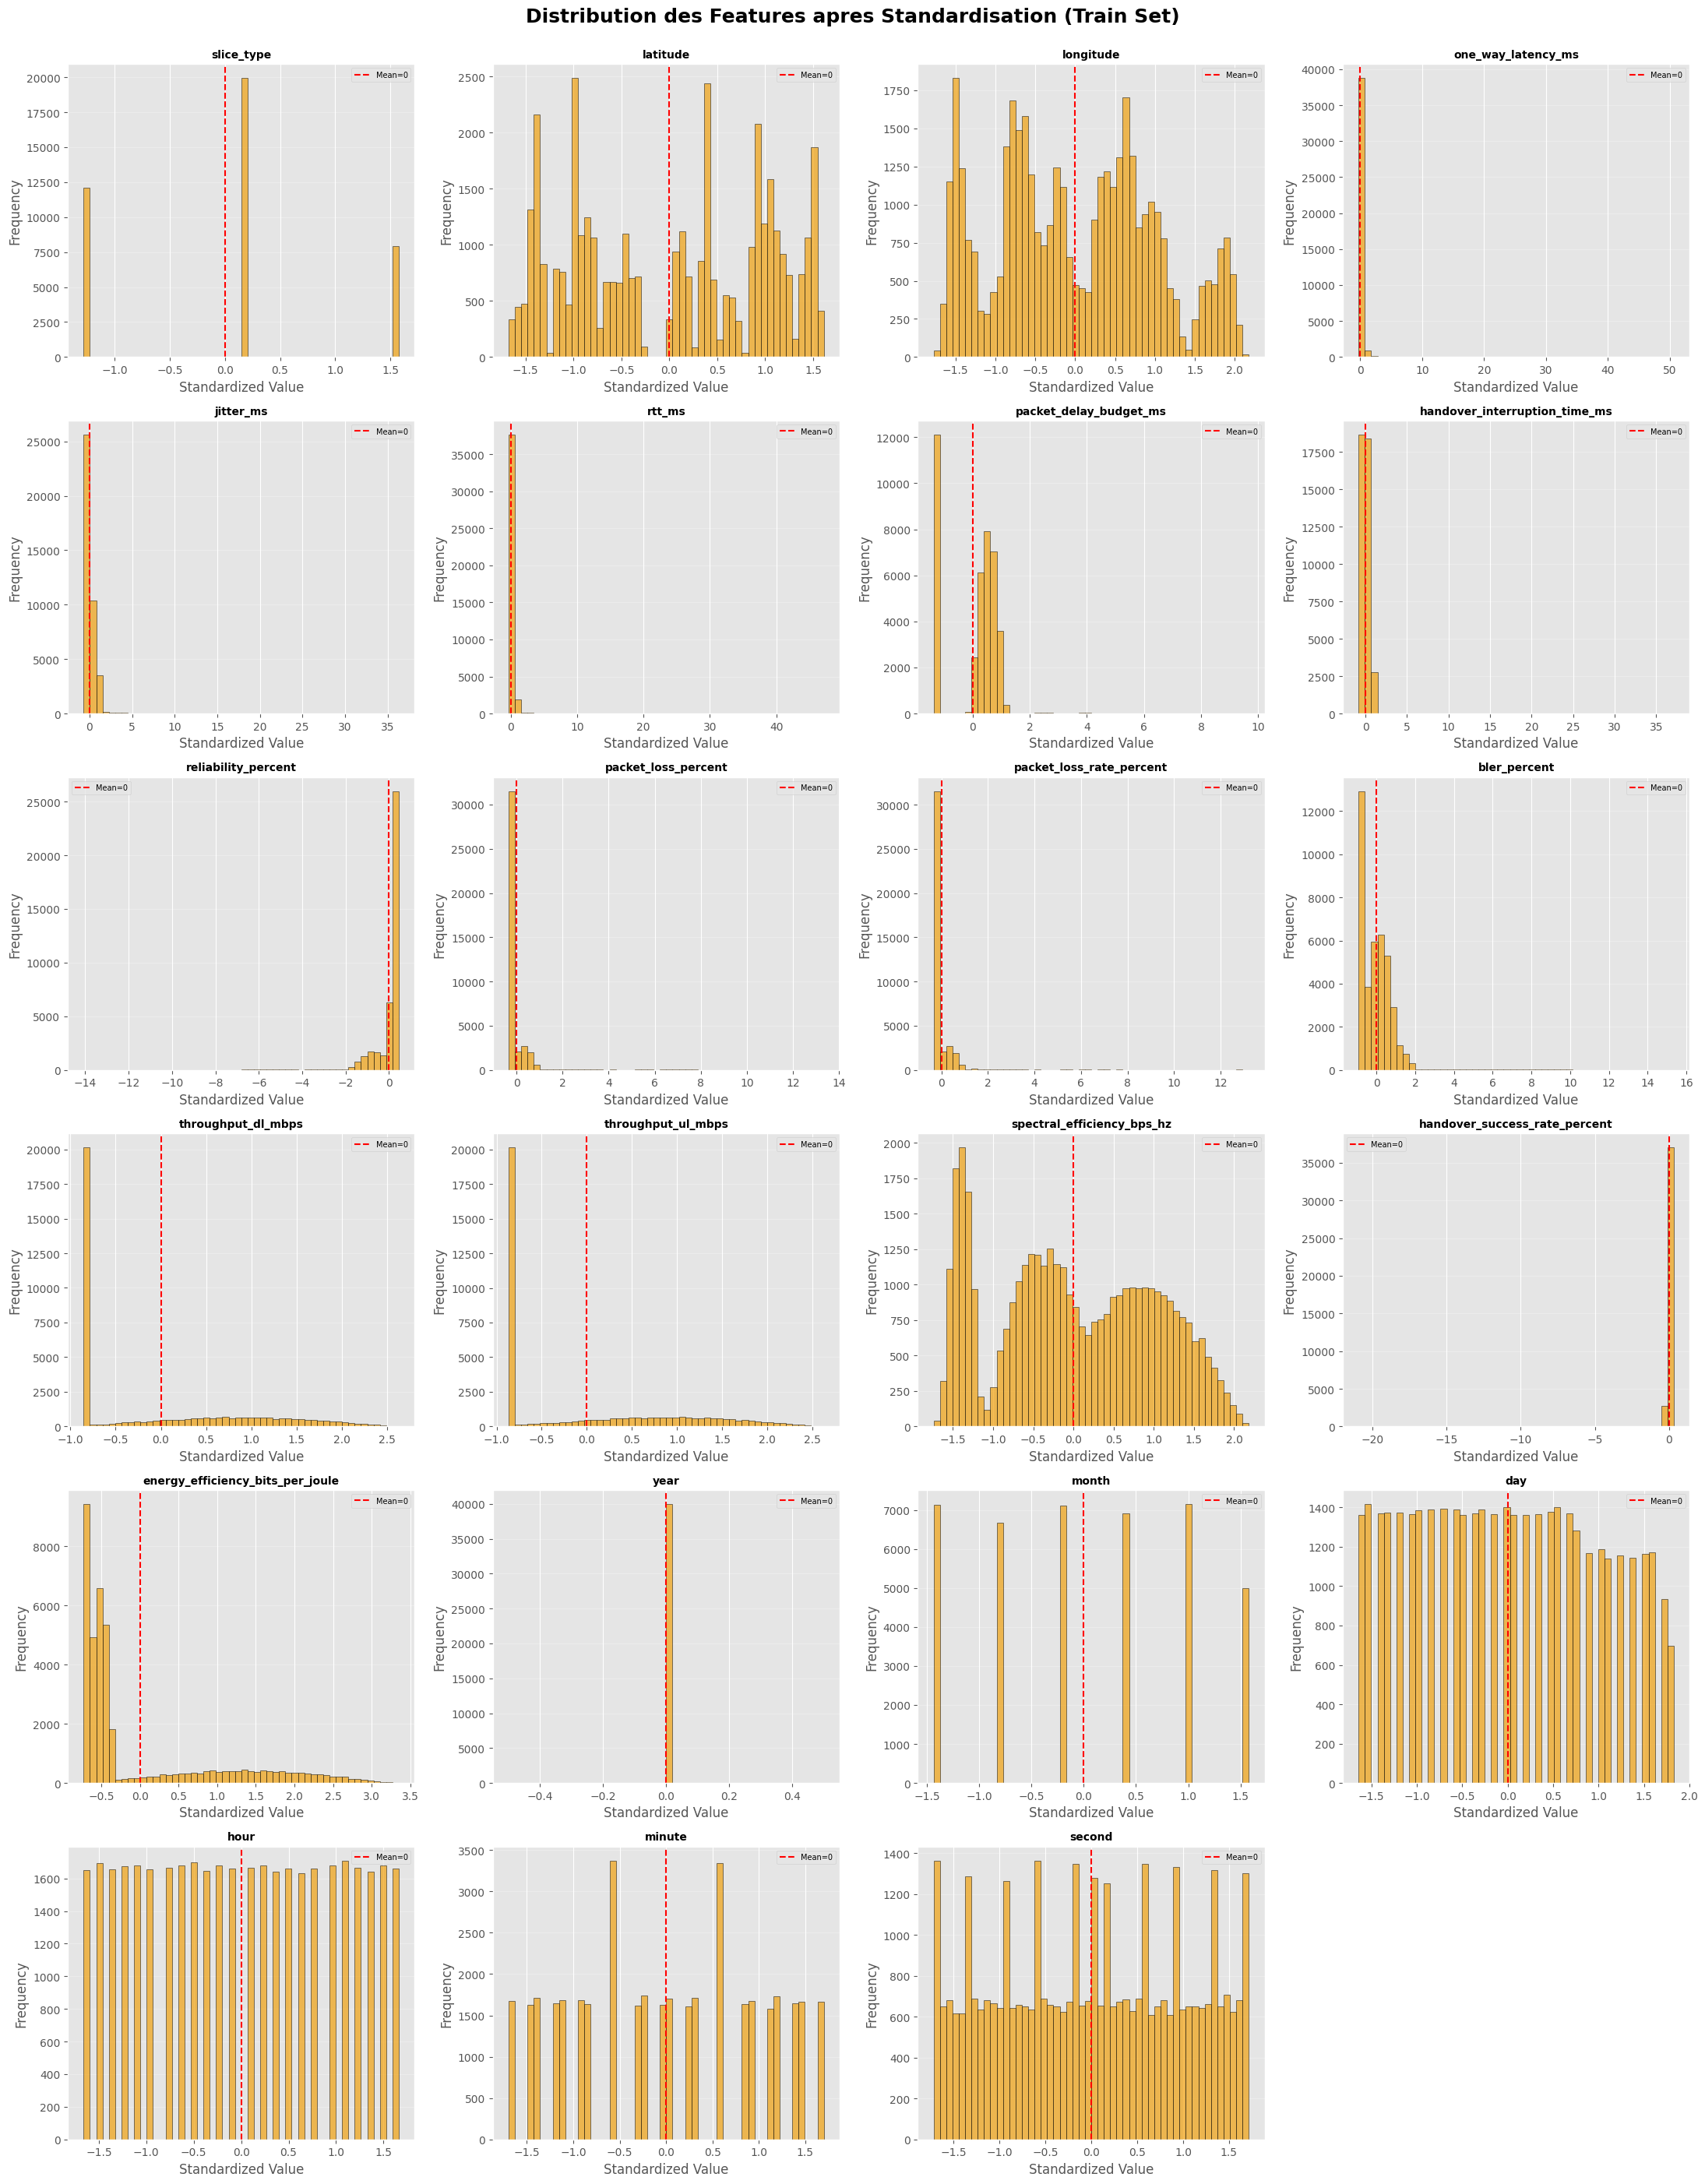

All 23 features are standardized (mean ~ 0, std ~ 1)


In [25]:
# =====================================================================
# 5. Distribution des Features apres Standardisation
# =====================================================================

fig, axes = plt.subplots(6, 4, figsize=(22, 28))
axes = axes.ravel()

for idx, col in enumerate(X_train_b_scaled.columns):
    axes[idx].hist(X_train_b_scaled[col], bins=50, color="#f0a10f",
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean=0')
    axes[idx].set_xlabel('Standardized Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplot (24 subplots, 23 features)
axes[-1].set_visible(False)

plt.suptitle('Distribution des Features apres Standardisation (Train Set)',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"All {X_train_b_scaled.shape[1]} features are standardized (mean ~ 0, std ~ 1)")

# =====================================================================
# MODÉLISATION KNN — avec StandardScaler
# =====================================================================

## 7. Modélisation — Classification Binaire (StandardScaler)
Entraînement du modèle KNN sur les données transformées par **StandardScaler** pour la détection d'anomalies (Normal vs Anomaly).

KNN BASELINE — CLASSIFICATION BINAIRE (StandardScaler)

Paramètres par défaut:
   n_neighbors: 5
   weights:     uniform
   metric:      minkowski

✅ Entraînement terminé en 0.00s

RÉSULTATS BASELINE — Classification Binaire (StandardScaler)

  Accuracy:  0.9920
  Precision: 1.0000
  Recall:    0.8384
  F1-Score:  0.9121
  ROC-AUC:   0.9465

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      9505
     Anomaly       1.00      0.84      0.91       495

    accuracy                           0.99     10000
   macro avg       1.00      0.92      0.95     10000
weighted avg       0.99      0.99      0.99     10000



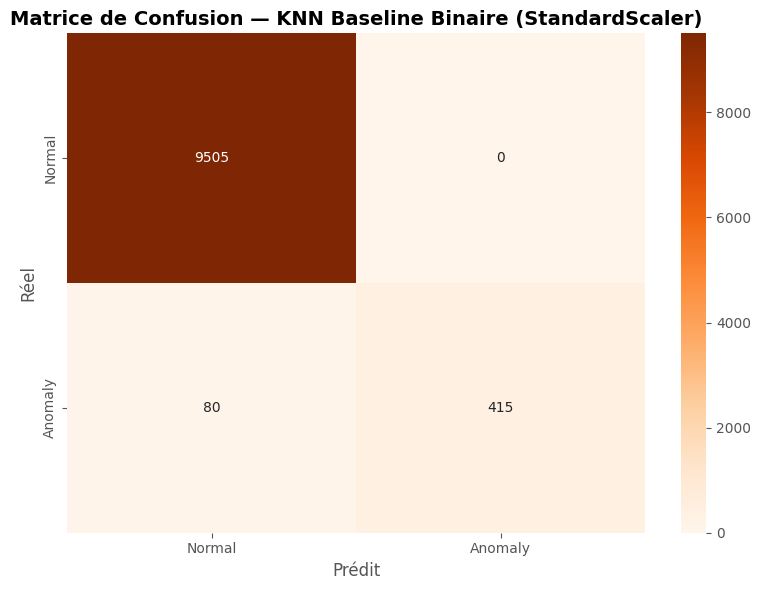

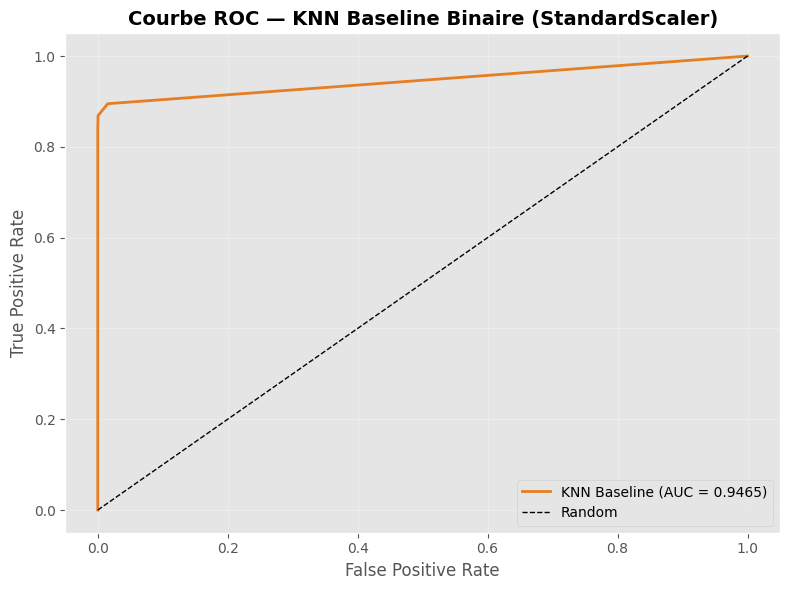

In [26]:
# =====================================================================
# 7.0 KNN Baseline — Classification Binaire (StandardScaler) — SANS GridSearch
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut (k=5) ---
print("="*70)
print("KNN BASELINE — CLASSIFICATION BINAIRE (StandardScaler)")
print("="*70)

knn_baseline = KNeighborsClassifier()  # Paramètres par défaut: n_neighbors=5, weights='uniform', metric='minkowski'

print(f"\nParamètres par défaut:")
print(f"   n_neighbors: {knn_baseline.n_neighbors}")
print(f"   weights:     {knn_baseline.weights}")
print(f"   metric:      {knn_baseline.metric}")

# --- Entraînement ---
start_time = time.time()
knn_baseline.fit(X_train_b_scaled, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = knn_baseline.predict(X_test_b_scaled)
y1_proba_baseline = knn_baseline.predict_proba(X_test_b_scaled)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — KNN Baseline Binaire (StandardScaler)', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'KNN Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — KNN Baseline Binaire (StandardScaler)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

KNN BASELINE — CLASSIFICATION MULTI-CLASSES (StandardScaler)

Paramètres par défaut:
   n_neighbors: 5
   weights:     uniform
   metric:      minkowski

✅ Entraînement terminé en 0.00s

RÉSULTATS BASELINE — Classification Multi-classes (StandardScaler)

  Accuracy:           0.9910
  Precision (weighted): 0.9909
  Recall (weighted):    0.9910
  F1-Score (weighted):  0.9901

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       1.00      0.61      0.76        64
  handover_failure       1.00      1.00      1.00        56
  hardware_failure       1.00      1.00      1.00        63
      interference       0.96      0.87      0.92        62
network_congestion       0.97      0.56      0.71        62
            normal       0.99      1.00      1.00      9505
          overload       0.98      0.66      0.79        62
   security_attack       1.00      1.00      1.00        62
signal_degradation       0.96      0.86      0.91       

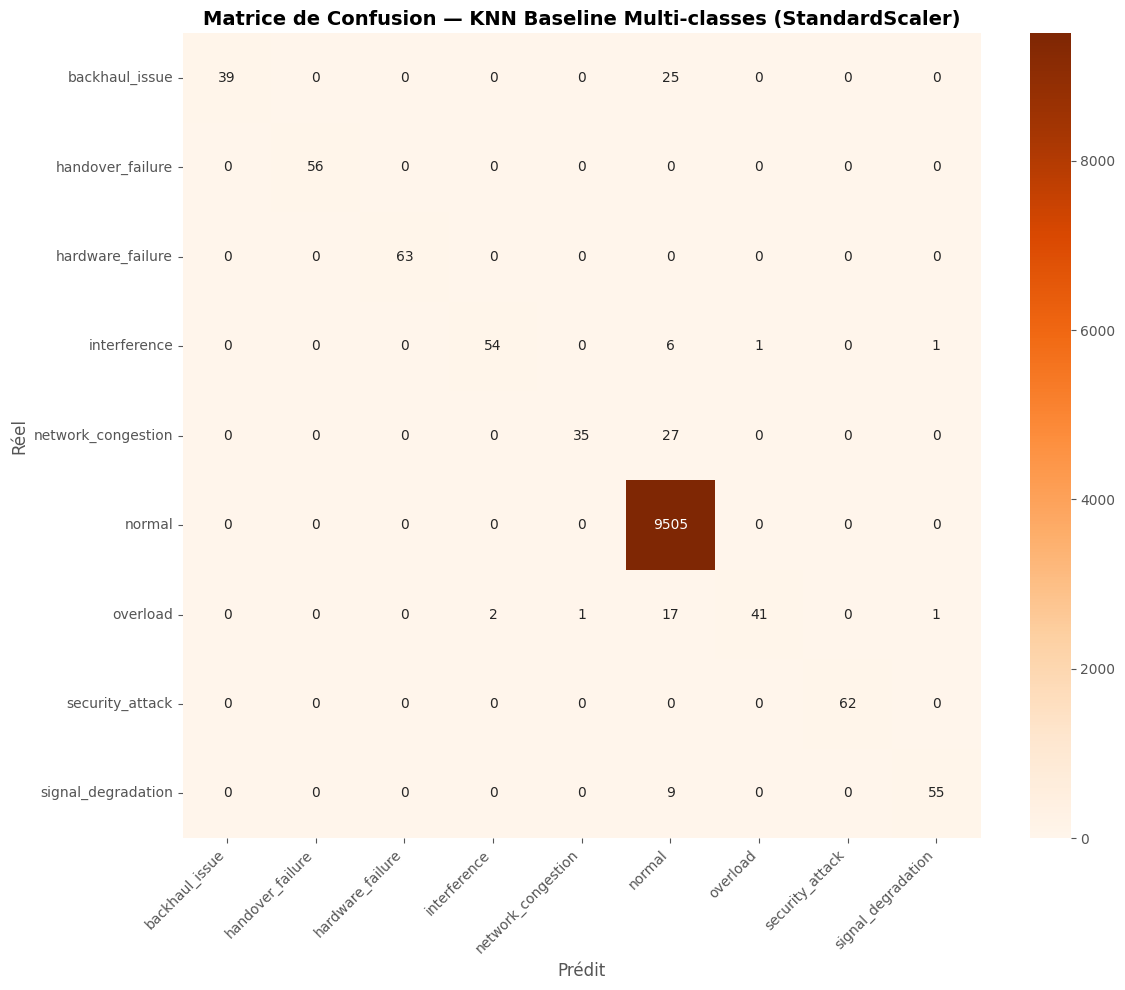


📋 RÉSUMÉ BASELINE KNN (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9920          0.9910
  Precision                     1.0000          0.9909
  Recall                        0.8384          0.9910
  F1-Score                      0.9121          0.9901

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [27]:
# =====================================================================
# 7.0.2 KNN Baseline — Classification Multi-classes (StandardScaler) — SANS GridSearch
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut (k=5) ---
print("="*70)
print("KNN BASELINE — CLASSIFICATION MULTI-CLASSES (StandardScaler)")
print("="*70)

knn_baseline_m = KNeighborsClassifier()

print(f"\nParamètres par défaut:")
print(f"   n_neighbors: {knn_baseline_m.n_neighbors}")
print(f"   weights:     {knn_baseline_m.weights}")
print(f"   metric:      {knn_baseline_m.metric}")

# --- Entraînement ---
start_time = time.time()
knn_baseline_m.fit(X_train_m_scaled, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = knn_baseline_m.predict(X_test_m_scaled)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — KNN Baseline Multi-classes (StandardScaler)', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE KNN (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

KNN — CLASSIFICATION BINAIRE (StandardScaler)

🔍 GridSearchCV en cours...
Fitting 5 folds for each of 28 candidates, totalling 140 fits



✅ GridSearchCV terminé en 35.50s
   Meilleurs paramètres: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
   Meilleur F1-score (CV): 0.9159

RÉSULTATS — Classification Binaire (StandardScaler)

  Accuracy:  0.9927
  Precision: 0.9953
  Recall:    0.8566
  F1-Score:  0.9207
  ROC-AUC:   0.9448

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      9505
     Anomaly       1.00      0.86      0.92       495

    accuracy                           0.99     10000
   macro avg       0.99      0.93      0.96     10000
weighted avg       0.99      0.99      0.99     10000



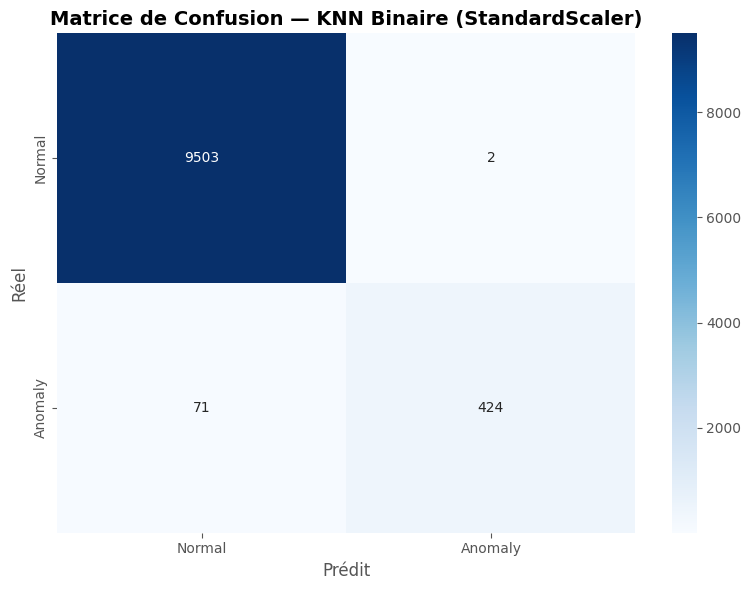

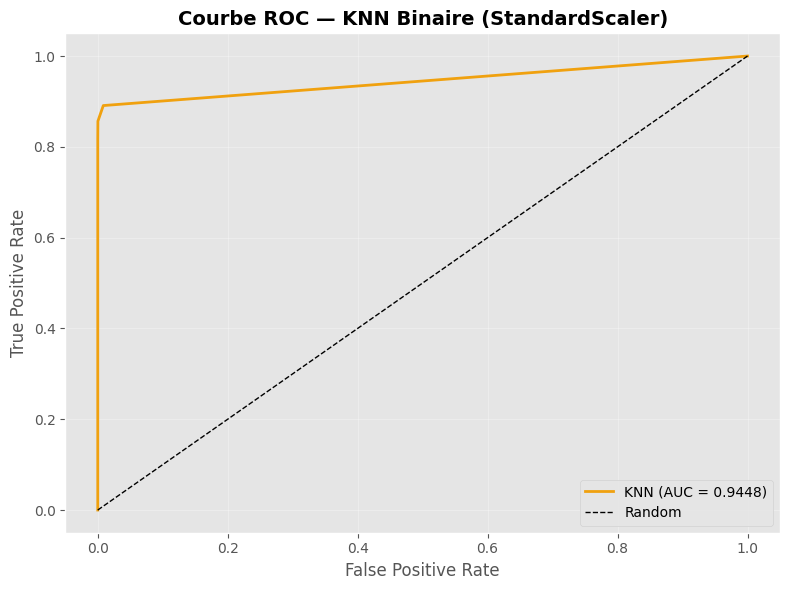

In [28]:
# =====================================================================
# 7.1 KNN — Classification Binaire (StandardScaler)
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV
import time

# --- GridSearchCV pour trouver le meilleur K ---
print("="*70)
print("KNN — CLASSIFICATION BINAIRE (StandardScaler)")
print("="*70)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 GridSearchCV en cours...")
start_time = time.time()
knn_grid.fit(X_train_b_scaled, y1_train)
grid_time = time.time() - start_time

print(f"\n✅ GridSearchCV terminé en {grid_time:.2f}s")
print(f"   Meilleurs paramètres: {knn_grid.best_params_}")
print(f"   Meilleur F1-score (CV): {knn_grid.best_score_:.4f}")

# --- Entraînement avec les meilleurs paramètres ---
best_knn_b = knn_grid.best_estimator_

# --- Prédictions ---
y1_pred = best_knn_b.predict(X_test_b_scaled)
y1_proba = best_knn_b.predict_proba(X_test_b_scaled)[:, 1]

# --- Métriques ---
print(f"\n{'='*70}")
print("RÉSULTATS — Classification Binaire (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:  {accuracy_score(y1_test, y1_pred):.4f}")
print(f"  Precision: {precision_score(y1_test, y1_pred):.4f}")
print(f"  Recall:    {recall_score(y1_test, y1_pred):.4f}")
print(f"  F1-Score:  {f1_score(y1_test, y1_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y1_test, y1_proba):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — KNN Binaire (StandardScaler)', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr, tpr, thresholds = roc_curve(y1_test, y1_proba)
auc_score = roc_auc_score(y1_test, y1_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#f0a10f', linewidth=2, label=f'KNN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — KNN Binaire (StandardScaler)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Modélisation — Classification Multi-classes (StandardScaler)
Entraînement du modèle KNN sur les données transformées par **StandardScaler** pour la classification des types d'anomalies.

KNN — CLASSIFICATION MULTI-CLASSES (StandardScaler)

🔍 GridSearchCV en cours...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ GridSearchCV terminé en 34.74s
   Meilleurs paramètres: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
   Meilleur F1-weighted (CV): 0.9907

RÉSULTATS — Classification Multi-classes (StandardScaler)

  Accuracy:          0.9916
  Precision (weighted): 0.9916
  Recall (weighted):    0.9916
  F1-Score (weighted):  0.9908

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       1.00      0.61      0.76        64
  handover_failure       1.00      1.00      1.00        56
  hardware_failure       1.00      1.00      1.00        63
      interference       0.97      0.92      0.94        62
network_congestion       0.97      0.56      0.71        62
            normal       0.99      1.00      1.00      9505
          overload       1.00      0.74      0.85        62
   securi

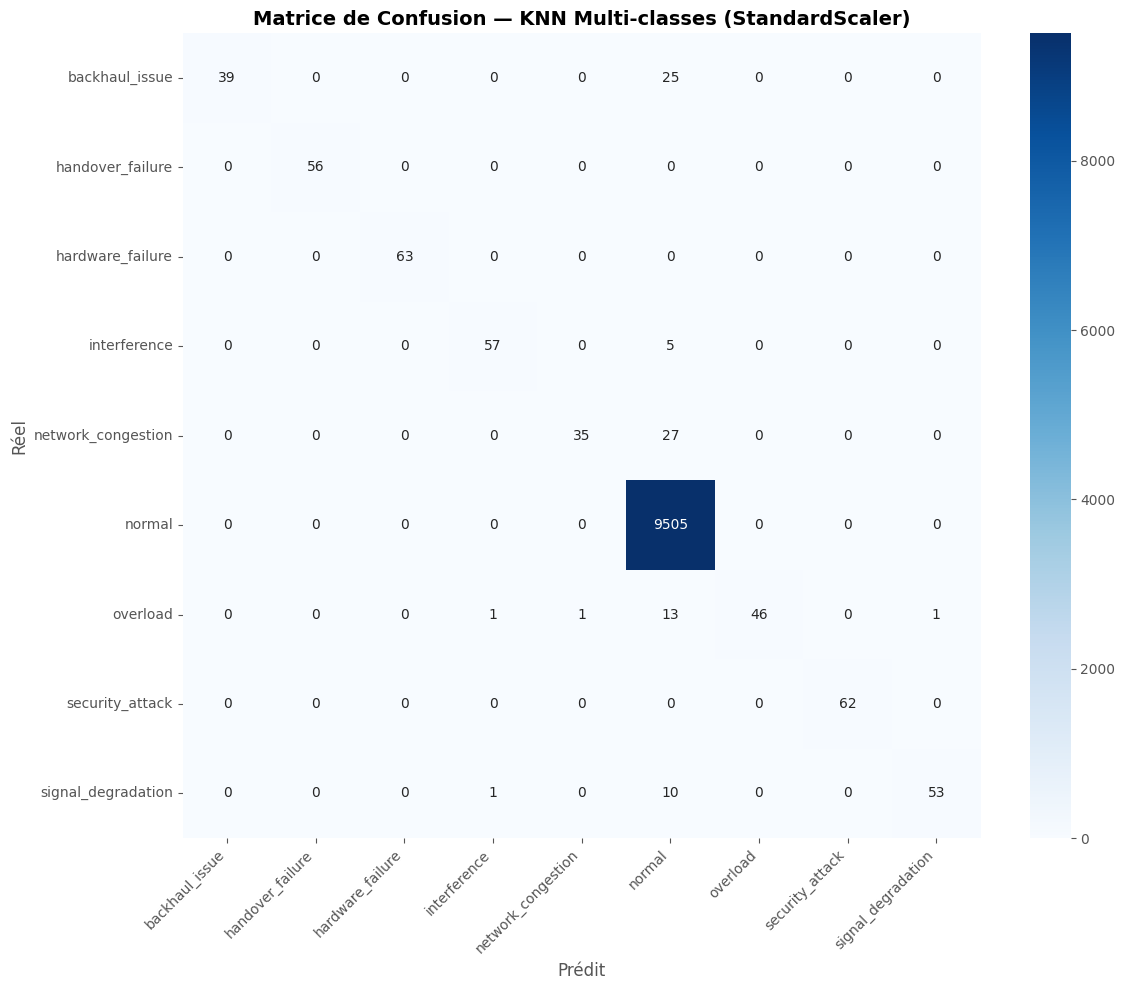


📊 Cross-Validation F1-weighted (5 folds):
   Scores: ['0.9911', '0.9899', '0.9904', '0.9921', '0.9900']
   Mean:   0.9907 ± 0.0008


In [29]:
# =====================================================================
# 8.1 KNN — Classification Multi-classes (StandardScaler)
# =====================================================================

print("="*70)
print("KNN — CLASSIFICATION MULTI-CLASSES (StandardScaler)")
print("="*70)

param_grid_m = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid_m = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_m,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 GridSearchCV en cours...")
start_time = time.time()
knn_grid_m.fit(X_train_m_scaled, y2_train)
grid_time_m = time.time() - start_time

print(f"\n✅ GridSearchCV terminé en {grid_time_m:.2f}s")
print(f"   Meilleurs paramètres: {knn_grid_m.best_params_}")
print(f"   Meilleur F1-weighted (CV): {knn_grid_m.best_score_:.4f}")

# --- Entraînement avec les meilleurs paramètres ---
best_knn_m = knn_grid_m.best_estimator_

# --- Prédictions ---
y2_pred = best_knn_m.predict(X_test_m_scaled)

# --- Métriques ---
print(f"\n{'='*70}")
print("RÉSULTATS — Classification Multi-classes (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:          {accuracy_score(y2_test, y2_pred):.4f}")
print(f"  Precision (weighted): {precision_score(y2_test, y2_pred, average='weighted'):.4f}")
print(f"  Recall (weighted):    {recall_score(y2_test, y2_pred, average='weighted'):.4f}")
print(f"  F1-Score (weighted):  {f1_score(y2_test, y2_pred, average='weighted'):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_m = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — KNN Multi-classes (StandardScaler)', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Cross-Validation Score ---
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_knn_m, X_train_m_scaled, y2_train, cv=5, scoring='f1_weighted')
print(f"\n📊 Cross-Validation F1-weighted (5 folds):")
print(f"   Scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [30]:
# =====================================================================
# Résumé des résultats KNN avec StandardScaler
# =====================================================================

print("="*70)
print("RÉSUMÉ — KNN avec StandardScaler")
print("="*70)

results_summary = pd.DataFrame({
    'Tâche': ['Binaire (Normal vs Anomaly)', 'Multi-classes (Types anomalies)'],
    'Accuracy': [
        accuracy_score(y1_test, y1_pred),
        accuracy_score(y2_test, y2_pred)
    ],
    'Precision': [
        precision_score(y1_test, y1_pred),
        precision_score(y2_test, y2_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y1_test, y1_pred),
        recall_score(y2_test, y2_pred, average='weighted')
    ],
    'F1-Score': [
        f1_score(y1_test, y1_pred),
        f1_score(y2_test, y2_pred, average='weighted')
    ]
})

results_summary = results_summary.set_index('Tâche')
print(results_summary.round(4).to_string())

print("\n💡 Ces résultats serviront de référence pour comparer avec QuantileTransformer.")

RÉSUMÉ — KNN avec StandardScaler
                                 Accuracy  Precision  Recall  F1-Score
Tâche                                                                 
Binaire (Normal vs Anomaly)        0.9927     0.9953  0.8566    0.9207
Multi-classes (Types anomalies)    0.9916     0.9916  0.9916    0.9908

💡 Ces résultats serviront de référence pour comparer avec QuantileTransformer.


## 9. Analyse d'Overfitting — KNN avec StandardScaler
Comparaison des performances **Train vs Test** et **Learning Curves** pour détecter un éventuel surapprentissage.

ANALYSE D'OVERFITTING — KNN avec StandardScaler

──────────────────────────────────────────────────────────────────────
📊 A) CLASSIFICATION BINAIRE
──────────────────────────────────────────────────────────────────────
            Train    Test  Écart (Train-Test)  Écart (%)
Métrique                                                
Accuracy   0.9939  0.9927              0.0012     0.1207
Precision  1.0000  0.9953              0.0047     0.4695
Recall     0.8768  0.8566              0.0203     2.3111
F1-Score   0.9344  0.9207              0.0136     1.4593
ROC-AUC    0.9996  0.9448              0.0548     5.4809

   Écart moyen Train-Test: 1.97%
   ✅ PAS d'overfitting — Le modèle généralise très bien

──────────────────────────────────────────────────────────────────────
📊 B) CLASSIFICATION MULTI-CLASSES
──────────────────────────────────────────────────────────────────────
               Train    Test  Écart (Train-Test)  Écart (%)
Métrique                                               

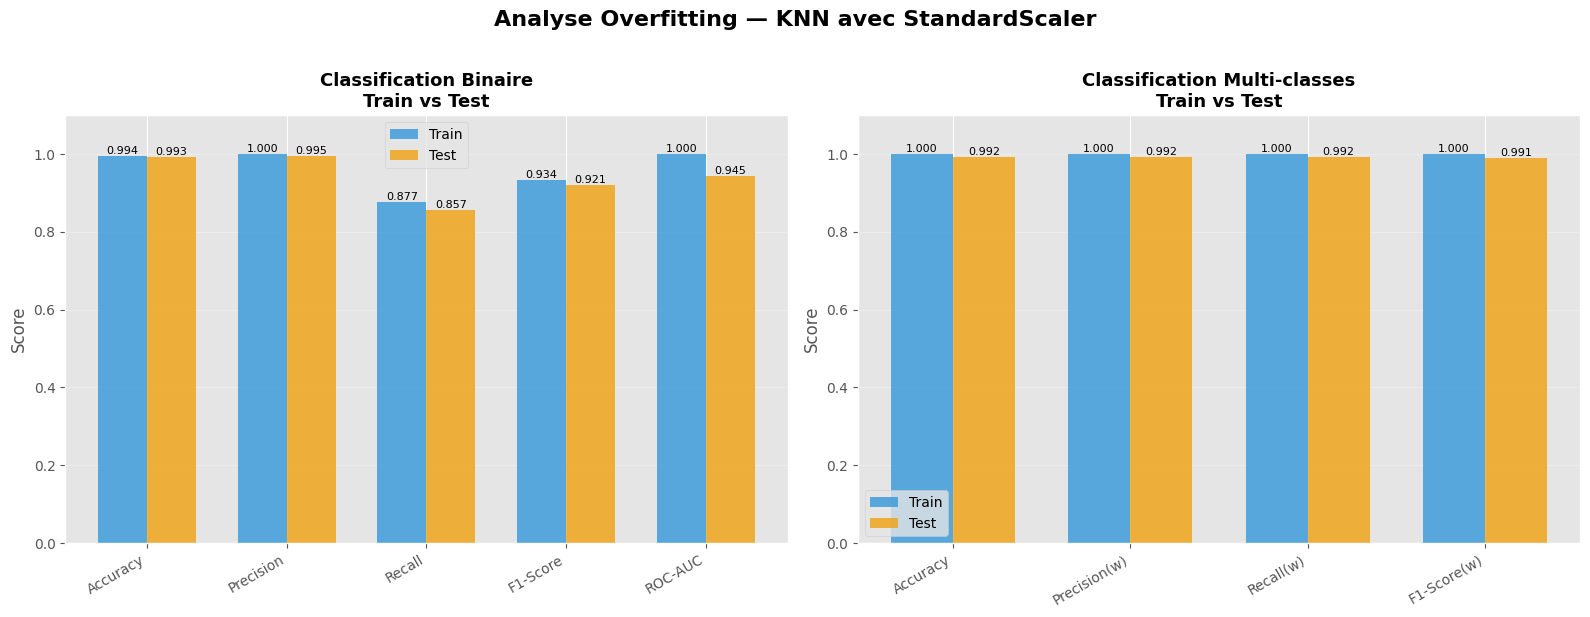

In [31]:
# =====================================================================
# 9.1 Overfitting Analysis — Train vs Test Scores
# =====================================================================
from sklearn.model_selection import learning_curve

print("="*70)
print("ANALYSE D'OVERFITTING — KNN avec StandardScaler")
print("="*70)

# ─────────────────────────────────────────────────────────────────────
# A) Classification Binaire — Train vs Test
# ─────────────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("📊 A) CLASSIFICATION BINAIRE")
print("─"*70)

# Prédictions sur le TRAIN set
y1_train_pred = best_knn_b.predict(X_train_b_scaled)
y1_train_proba = best_knn_b.predict_proba(X_train_b_scaled)[:, 1]

# Métriques Train
train_acc_b = accuracy_score(y1_train, y1_train_pred)
train_f1_b = f1_score(y1_train, y1_train_pred)
train_prec_b = precision_score(y1_train, y1_train_pred)
train_rec_b = recall_score(y1_train, y1_train_pred)
train_auc_b = roc_auc_score(y1_train, y1_train_proba)

# Métriques Test
test_acc_b = accuracy_score(y1_test, y1_pred)
test_f1_b = f1_score(y1_test, y1_pred)
test_prec_b = precision_score(y1_test, y1_pred)
test_rec_b = recall_score(y1_test, y1_pred)
test_auc_b = roc_auc_score(y1_test, y1_proba)

# Tableau comparatif
overfitting_b = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Train': [train_acc_b, train_prec_b, train_rec_b, train_f1_b, train_auc_b],
    'Test': [test_acc_b, test_prec_b, test_rec_b, test_f1_b, test_auc_b],
})
overfitting_b['Écart (Train-Test)'] = overfitting_b['Train'] - overfitting_b['Test']
overfitting_b['Écart (%)'] = ((overfitting_b['Train'] - overfitting_b['Test']) / overfitting_b['Train'] * 100)
overfitting_b = overfitting_b.set_index('Métrique')

print(overfitting_b.round(4).to_string())

# Diagnostic binaire
avg_gap_b = overfitting_b['Écart (%)'].mean()
print(f"\n   Écart moyen Train-Test: {avg_gap_b:.2f}%")

if avg_gap_b < 2:
    print("   ✅ PAS d'overfitting — Le modèle généralise très bien")
elif avg_gap_b < 5:
    print("   🟡 Léger overfitting — Acceptable mais à surveiller")
elif avg_gap_b < 10:
    print("   🟠 Overfitting modéré — Envisager une régularisation")
else:
    print("   🔴 Overfitting significatif — Le modèle mémorise trop le train set")

# ─────────────────────────────────────────────────────────────────────
# B) Classification Multi-classes — Train vs Test
# ─────────────────────────────────────────────────────────────────────
print("\n" + "─"*70)
print("📊 B) CLASSIFICATION MULTI-CLASSES")
print("─"*70)

# Prédictions sur le TRAIN set
y2_train_pred = best_knn_m.predict(X_train_m_scaled)

# Métriques Train
train_acc_m = accuracy_score(y2_train, y2_train_pred)
train_f1_m = f1_score(y2_train, y2_train_pred, average='weighted')
train_prec_m = precision_score(y2_train, y2_train_pred, average='weighted')
train_rec_m = recall_score(y2_train, y2_train_pred, average='weighted')

# Métriques Test
test_acc_m = accuracy_score(y2_test, y2_pred)
test_f1_m = f1_score(y2_test, y2_pred, average='weighted')
test_prec_m = precision_score(y2_test, y2_pred, average='weighted')
test_rec_m = recall_score(y2_test, y2_pred, average='weighted')

# Tableau comparatif
overfitting_m = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision (w)', 'Recall (w)', 'F1-Score (w)'],
    'Train': [train_acc_m, train_prec_m, train_rec_m, train_f1_m],
    'Test': [test_acc_m, test_prec_m, test_rec_m, test_f1_m],
})
overfitting_m['Écart (Train-Test)'] = overfitting_m['Train'] - overfitting_m['Test']
overfitting_m['Écart (%)'] = ((overfitting_m['Train'] - overfitting_m['Test']) / overfitting_m['Train'] * 100)
overfitting_m = overfitting_m.set_index('Métrique')

print(overfitting_m.round(4).to_string())

# Diagnostic multi-classes
avg_gap_m = overfitting_m['Écart (%)'].mean()
print(f"\n   Écart moyen Train-Test: {avg_gap_m:.2f}%")

if avg_gap_m < 2:
    print("   ✅ PAS d'overfitting — Le modèle généralise très bien")
elif avg_gap_m < 5:
    print("   🟡 Léger overfitting — Acceptable mais à surveiller")
elif avg_gap_m < 10:
    print("   🟠 Overfitting modéré — Envisager une régularisation")
else:
    print("   🔴 Overfitting significatif — Le modèle mémorise trop le train set")

# ─────────────────────────────────────────────────────────────────────
# C) Visualisation Train vs Test
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binaire
metrics_b = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
train_vals_b = [train_acc_b, train_prec_b, train_rec_b, train_f1_b, train_auc_b]
test_vals_b = [test_acc_b, test_prec_b, test_rec_b, test_f1_b, test_auc_b]

x = np.arange(len(metrics_b))
width = 0.35
bars1 = axes[0].bar(x - width/2, train_vals_b, width, label='Train', color='#3498db', alpha=0.8)
bars2 = axes[0].bar(x + width/2, test_vals_b, width, label='Test', color='#f0a10f', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Binaire\nTrain vs Test', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_b, rotation=30, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].annotate(f'{bar.get_height():.3f}', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].annotate(f'{bar.get_height():.3f}', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Multi-classes
metrics_m = ['Accuracy', 'Precision(w)', 'Recall(w)', 'F1-Score(w)']
train_vals_m = [train_acc_m, train_prec_m, train_rec_m, train_f1_m]
test_vals_m = [test_acc_m, test_prec_m, test_rec_m, test_f1_m]

x2 = np.arange(len(metrics_m))
bars3 = axes[1].bar(x2 - width/2, train_vals_m, width, label='Train', color='#3498db', alpha=0.8)
bars4 = axes[1].bar(x2 + width/2, test_vals_m, width, label='Test', color='#f0a10f', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Multi-classes\nTrain vs Test', fontsize=13, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics_m, rotation=30, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for bar in bars3:
    axes[1].annotate(f'{bar.get_height():.3f}', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].annotate(f'{bar.get_height():.3f}', (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.suptitle('Analyse Overfitting — KNN avec StandardScaler', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

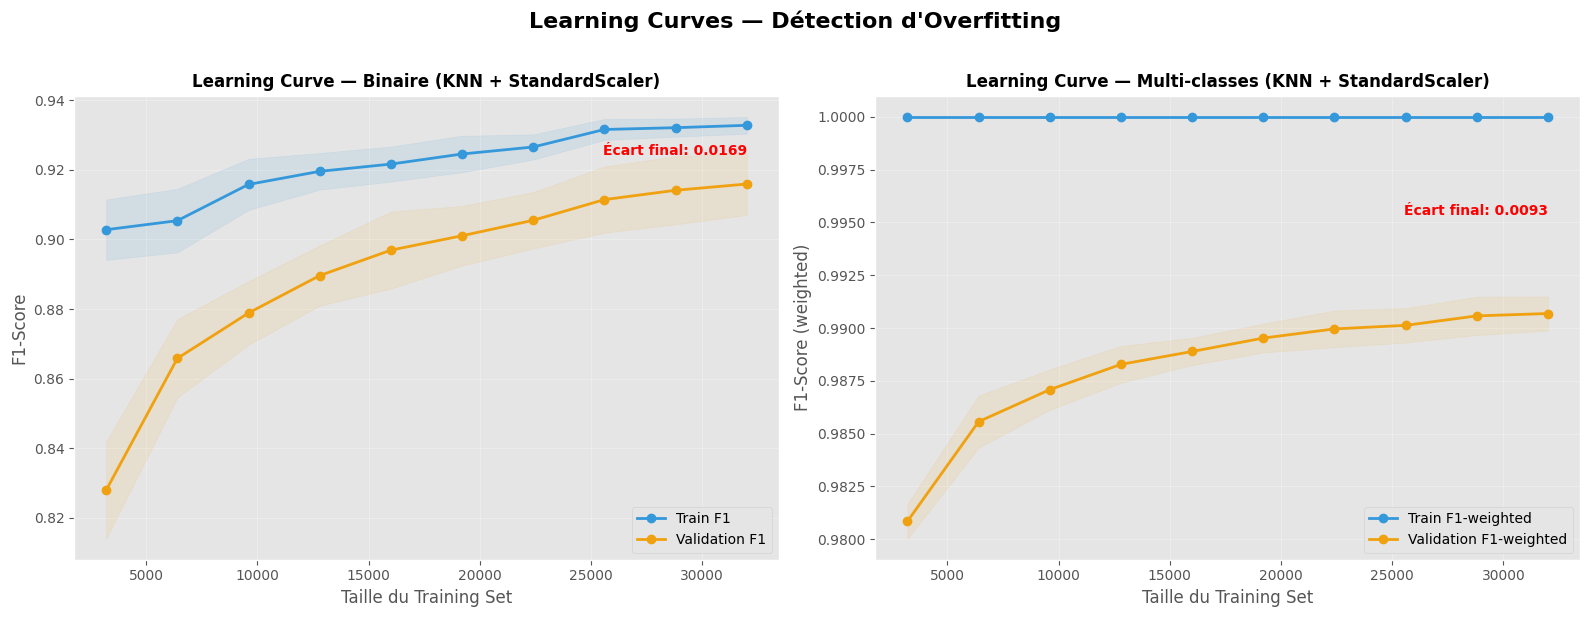

📊 INTERPRÉTATION DES LEARNING CURVES

📌 Classification Binaire:
   Train F1 final:      0.9328
   Validation F1 final: 0.9159
   Écart:               0.0169 (1.81%)
   ✅ Les courbes convergent → PAS d'overfitting

📌 Classification Multi-classes:
   Train F1-w final:      1.0000
   Validation F1-w final: 0.9907
   Écart:                 0.0093 (0.93%)
   ✅ Les courbes convergent → PAS d'overfitting

──────────────────────────────────────────────────────────────────────
📊 Impact du K sur l'Overfitting (Binaire)
──────────────────────────────────────────────────────────────────────
 K  Train F1  Test F1  Écart Overfitting?
 1    1.0000   0.9118 0.0882        🔴 OUI
 3    0.9344   0.9207 0.0136        ✅ NON
 5    0.9216   0.9121 0.0095        ✅ NON
 7    0.9136   0.9085 0.0051        ✅ NON
 9    0.9076   0.9000 0.0076        ✅ NON
11    0.9016   0.8926 0.0090        ✅ NON
15    0.8874   0.8801 0.0073        ✅ NON
21    0.8725   0.8699 0.0026        ✅ NON
31    0.8503   0.8435 0.0068        

In [32]:
# =====================================================================
# 9.2 Learning Curves — Détection visuelle d'overfitting
# =====================================================================
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Learning Curve: Binaire ---
train_sizes_b, train_scores_b, test_scores_b = learning_curve(
    best_knn_b, X_train_b_scaled, y1_train,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=42
)

train_mean_b = train_scores_b.mean(axis=1)
train_std_b = train_scores_b.std(axis=1)
test_mean_b = test_scores_b.mean(axis=1)
test_std_b = test_scores_b.std(axis=1)

axes[0].fill_between(train_sizes_b, train_mean_b - train_std_b, train_mean_b + train_std_b, alpha=0.1, color='#3498db')
axes[0].fill_between(train_sizes_b, test_mean_b - test_std_b, test_mean_b + test_std_b, alpha=0.1, color='#f0a10f')
axes[0].plot(train_sizes_b, train_mean_b, 'o-', color='#3498db', linewidth=2, label='Train F1')
axes[0].plot(train_sizes_b, test_mean_b, 'o-', color='#f0a10f', linewidth=2, label='Validation F1')
axes[0].set_xlabel('Taille du Training Set')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Learning Curve — Binaire (KNN + StandardScaler)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Annoter l'écart final
gap_b = train_mean_b[-1] - test_mean_b[-1]
axes[0].annotate(f'Écart final: {gap_b:.4f}', 
                 xy=(train_sizes_b[-1], (train_mean_b[-1] + test_mean_b[-1])/2),
                 fontsize=10, fontweight='bold', color='red',
                 ha='right')

# --- Learning Curve: Multi-classes ---
train_sizes_m, train_scores_m, test_scores_m = learning_curve(
    best_knn_m, X_train_m_scaled, y2_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=42
)

train_mean_m = train_scores_m.mean(axis=1)
train_std_m = train_scores_m.std(axis=1)
test_mean_m = test_scores_m.mean(axis=1)
test_std_m = test_scores_m.std(axis=1)

axes[1].fill_between(train_sizes_m, train_mean_m - train_std_m, train_mean_m + train_std_m, alpha=0.1, color='#3498db')
axes[1].fill_between(train_sizes_m, test_mean_m - test_std_m, test_mean_m + test_std_m, alpha=0.1, color='#f0a10f')
axes[1].plot(train_sizes_m, train_mean_m, 'o-', color='#3498db', linewidth=2, label='Train F1-weighted')
axes[1].plot(train_sizes_m, test_mean_m, 'o-', color='#f0a10f', linewidth=2, label='Validation F1-weighted')
axes[1].set_xlabel('Taille du Training Set')
axes[1].set_ylabel('F1-Score (weighted)')
axes[1].set_title('Learning Curve — Multi-classes (KNN + StandardScaler)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Annoter l'écart final
gap_m = train_mean_m[-1] - test_mean_m[-1]
axes[1].annotate(f'Écart final: {gap_m:.4f}',
                 xy=(train_sizes_m[-1], (train_mean_m[-1] + test_mean_m[-1])/2),
                 fontsize=10, fontweight='bold', color='red',
                 ha='right')

plt.suptitle('Learning Curves — Détection d\'Overfitting', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────
# Interprétation des Learning Curves
# ─────────────────────────────────────────────────────────────────────
print("="*70)
print("📊 INTERPRÉTATION DES LEARNING CURVES")
print("="*70)

print(f"\n📌 Classification Binaire:")
print(f"   Train F1 final:      {train_mean_b[-1]:.4f}")
print(f"   Validation F1 final: {test_mean_b[-1]:.4f}")
print(f"   Écart:               {gap_b:.4f} ({gap_b/train_mean_b[-1]*100:.2f}%)")

if gap_b < 0.02:
    print("   ✅ Les courbes convergent → PAS d'overfitting")
elif gap_b < 0.05:
    print("   🟡 Léger écart → Overfitting minime, acceptable")
else:
    print("   🔴 Écart important → Overfitting détecté")

print(f"\n📌 Classification Multi-classes:")
print(f"   Train F1-w final:      {train_mean_m[-1]:.4f}")
print(f"   Validation F1-w final: {test_mean_m[-1]:.4f}")
print(f"   Écart:                 {gap_m:.4f} ({gap_m/train_mean_m[-1]*100:.2f}%)")

if gap_m < 0.02:
    print("   ✅ Les courbes convergent → PAS d'overfitting")
elif gap_m < 0.05:
    print("   🟡 Léger écart → Overfitting minime, acceptable")
else:
    print("   🔴 Écart important → Overfitting détecté")

# ─────────────────────────────────────────────────────────────────────
# Analyse de l'impact du K sur l'overfitting
# ─────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("📊 Impact du K sur l'Overfitting (Binaire)")
print("─"*70)

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_analysis = []

for k in k_values:
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        weights=best_knn_b.get_params()['weights'],
        metric=best_knn_b.get_params()['metric']
    )
    knn_temp.fit(X_train_b_scaled, y1_train)
    
    train_f1 = f1_score(y1_train, knn_temp.predict(X_train_b_scaled))
    test_f1 = f1_score(y1_test, knn_temp.predict(X_test_b_scaled))
    
    k_analysis.append({
        'K': k,
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        'Écart': round(train_f1 - test_f1, 4),
        'Overfitting?': '🔴 OUI' if (train_f1 - test_f1) > 0.05 else ('🟡 Léger' if (train_f1 - test_f1) > 0.02 else '✅ NON')
    })

k_df = pd.DataFrame(k_analysis)
print(k_df.to_string(index=False))

best_k = best_knn_b.get_params()['n_neighbors']
print(f"\n💡 K sélectionné par GridSearchCV: {best_k}")
print(f"   → Plus K est grand, moins il y a d'overfitting (mais risque d'underfitting)")
print(f"   → K={best_k} offre le meilleur compromis biais/variance")

In [33]:
# Solution anti-overfitting efficace pour KNN
# - Standardisation dans un Pipeline (évite les fuites)
# - PCA pour réduire le bruit
# - CV stratifiée
# - Recherche sur des K plus grands + poids uniformes

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'pca__n_components': [None, 0.90, 0.95],
    'knn__n_neighbors': list(range(9, 52, 2)),
    'knn__weights': ['uniform'],
    'knn__metric': ['manhattan', 'euclidean']
}

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('knn', KNeighborsClassifier())
])

print('=' * 70)
print('RE-ENTRAINEMENT KNN ROBUSTE (ANTI-OVERFITTING)')
print('=' * 70)

# Binaire
search_b = RandomizedSearchCV(
    estimator=pipeline_knn,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_b.fit(X_train_b, y1_train)

best_b = search_b.best_estimator_
train_f1_b_new = f1_score(y1_train, best_b.predict(X_train_b))
test_f1_b_new = f1_score(y1_test, best_b.predict(X_test_b))
gap_b_new = train_f1_b_new - test_f1_b_new

print('\n[Binaire]')
print('Best params:', search_b.best_params_)
print(f'Train F1: {train_f1_b_new:.4f}')
print(f'Test  F1: {test_f1_b_new:.4f}')
print(f'Gap   F1: {gap_b_new:.4f} ({gap_b_new * 100:.2f}%)')

# Multiclasse
search_m = RandomizedSearchCV(
    estimator=pipeline_knn,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_m.fit(X_train_m, y2_train)

best_m = search_m.best_estimator_
train_f1_m_new = f1_score(y2_train, best_m.predict(X_train_m), average='weighted')
test_f1_m_new = f1_score(y2_test, best_m.predict(X_test_m), average='weighted')
gap_m_new = train_f1_m_new - test_f1_m_new

print('\n[Multiclasse]')
print('Best params:', search_m.best_params_)
print(f'Train F1w: {train_f1_m_new:.4f}')
print(f'Test  F1w: {test_f1_m_new:.4f}')
print(f'Gap   F1w: {gap_m_new:.4f} ({gap_m_new * 100:.2f}%)')

print('\nInterprétation rapide:')
print('- Gap <= 0.02  : généralisation excellente')
print('- Gap 0.02-0.05: léger overfitting (souvent acceptable)')
print('- Gap > 0.05   : overfitting à corriger davantage')

RE-ENTRAINEMENT KNN ROBUSTE (ANTI-OVERFITTING)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[Binaire]
Best params: {'pca__n_components': None, 'knn__weights': 'uniform', 'knn__n_neighbors': 9, 'knn__metric': 'manhattan'}
Train F1: 0.9160
Test  F1: 0.9133
Gap   F1: 0.0027 (0.27%)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

[Multiclasse]
Best params: {'pca__n_components': None, 'knn__weights': 'uniform', 'knn__n_neighbors': 9, 'knn__metric': 'manhattan'}
Train F1w: 0.9913
Test  F1w: 0.9903
Gap   F1w: 0.0010 (0.10%)

Interprétation rapide:
- Gap <= 0.02  : généralisation excellente
- Gap 0.02-0.05: léger overfitting (souvent acceptable)
- Gap > 0.05   : overfitting à corriger davantage


In [35]:
# =====================================================================
# TABLEAU PROFESSIONNEL - Comparaison des modeles KNN
# =====================================================================
from IPython.display import display

# 1) Construire le tableau de synthese
presentation_df = summary_df.copy()

# 2) Ajouter des colonnes de gain par rapport au baseline de chaque tache
baseline_f1_map = (
    presentation_df[presentation_df['Model'] == 'Baseline (default KNN)']
    .set_index('Task')['F1']
    .to_dict()
)

presentation_df['F1 Gain vs Baseline'] = presentation_df.apply(
    lambda r: r['F1'] - baseline_f1_map.get(r['Task'], np.nan), axis=1
)

# 3) Classement interne par tache
presentation_df['Rank (by F1)'] = presentation_df.groupby('Task')['F1'].rank(
    ascending=False, method='dense'
).astype(int)

# 4) Réorganiser les colonnes
presentation_df = presentation_df[[
    'Task', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC',
    'Train-Test F1 Gap', 'F1 Gain vs Baseline', 'Rank (by F1)'
]]

# 5) Verrouiller l'ordre des lignes pour une lecture executive
model_order = {
    'Baseline (default KNN)': 0,
    'Optimized (GridSearchCV)': 1,
    'Optimized Robust (Pipeline + RandomizedSearchCV)': 2
}
presentation_df['ModelOrder'] = presentation_df['Model'].map(model_order)
presentation_df = presentation_df.sort_values(['Task', 'ModelOrder']).drop(columns='ModelOrder').reset_index(drop=True)

# 6) Afficher une vue texte propre (utile pour export console)
print('=' * 120)
print('EXECUTIVE SUMMARY - KNN BASELINE VS OPTIMIZED')
print('=' * 120)
print(presentation_df.round(4).to_string(index=False))

# 7) Afficher une vue stylisee (utile pour presentation notebook)
styled = (
    presentation_df.style
    .format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1': '{:.4f}',
        'ROC-AUC': '{:.4f}',
        'Train-Test F1 Gap': '{:.4f}',
        'F1 Gain vs Baseline': '{:+.4f}',
        'Rank (by F1)': '{:d}'
    }, na_rep='-')
    .background_gradient(subset=['F1'], cmap='Greens')
    .background_gradient(subset=['Train-Test F1 Gap'], cmap='Reds_r')
    .background_gradient(subset=['F1 Gain vs Baseline'], cmap='Blues')
    .set_properties(subset=['Task', 'Model'], **{'font-weight': 'bold'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#1f2937'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .set_caption('Tableau comparatif professionnel - KNN (Baseline vs Optimized)')
)

display(styled)

# 8) Recommendation automatique concise
winner_df = presentation_df.loc[presentation_df.groupby('Task')['F1'].idxmax(), ['Task', 'Model', 'F1', 'Train-Test F1 Gap']]
print('\nRecommended models by task:')
print(winner_df.round(4).to_string(index=False))

EXECUTIVE SUMMARY - KNN BASELINE VS OPTIMIZED
       Task                                            Model  Accuracy  Precision  Recall     F1  ROC-AUC  Train-Test F1 Gap  F1 Gain vs Baseline  Rank (by F1)
     Binary                           Baseline (default KNN)    0.9920     1.0000  0.8384 0.9121   0.9465                NaN               0.0000             3
     Binary                         Optimized (GridSearchCV)    0.9927     0.9953  0.8566 0.9207   0.9448             0.0136               0.0087             1
     Binary Optimized Robust (Pipeline + RandomizedSearchCV)    0.9921     1.0000  0.8404 0.9133   0.9576             0.0027               0.0012             2
Multi-class                           Baseline (default KNN)    0.9910     0.9909  0.9910 0.9901      NaN                NaN               0.0000             3
Multi-class                         Optimized (GridSearchCV)    0.9916     0.9916  0.9916 0.9908      NaN             0.0092               0.0007         

,Task,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train-Test F1 Gap,F1 Gain vs Baseline,Rank (by F1)
0,Binary,Baseline (default KNN),0.9920,1.0000,0.8384,0.9121,0.9465,-,+0.0000,3
1,Binary,Optimized (GridSearchCV),0.9927,0.9953,0.8566,0.9207,0.9448,0.0136,+0.0087,1
2,Binary,Optimized Robust (Pipeline + RandomizedSearchCV),0.9921,1.0000,0.8404,0.9133,0.9576,0.0027,+0.0012,2
3,Multi-class,Baseline (default KNN),0.9910,0.9909,0.9910,0.9901,-,-,+0.0000,3
4,Multi-class,Optimized (GridSearchCV),0.9916,0.9916,0.9916,0.9908,-,0.0092,+0.0007,1
5,Multi-class,Optimized Robust (Pipeline + RandomizedSearchCV),0.9912,0.9912,0.9912,0.9903,-,0.0010,+0.0002,2



Recommended models by task:
       Task                    Model     F1  Train-Test F1 Gap
     Binary Optimized (GridSearchCV) 0.9207             0.0136
Multi-class Optimized (GridSearchCV) 0.9908             0.0092
